In [1]:
#%%
import cellpose.core
import time, os, sys
from urllib.parse import urlparse
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns
mpl.rcParams['figure.dpi'] = 300
from cellpose import utils, io
from cellpose import models, io
import cellpose
import pandas as pd
import numpy as np
from skimage.io import imread
import scipy as sp
from cellpose import plot
from scipy.signal import savgol_filter
from scipy.optimize import linear_sum_assignment
from scipy.spatial.distance import cdist
from skimage.segmentation import find_boundaries
from skimage.filters import threshold_local
import imageio
from skimage import filters, io, color


from sklearn.linear_model import LogisticRegression
from sklearn.metrics import f1_score, matthews_corrcoef

plt.rcParams["figure.figsize"] = (3,3)
plt.rcParams["figure.dpi"] = 100
%matplotlib inline



In [2]:
cellpose.core.use_gpu()

True

In [3]:
model = models.CellposeModel(gpu=True, model_type='cyto2')
chan = [[0,0]]

model_type argument is not used in v4.0.1+. Ignoring this argument...


In [4]:
data_directory='/n/boslfs02/LABS/murray_lab/Users/pnanda/DCS/Manuscript/eDCS031_scGFP_Glux_bex/Repeat/BE20/'
pwd_loc=!pwd
save_directory=pwd_loc[0]+'/Masks/'

In [5]:
files=os.listdir(data_directory)

In [6]:
import os
import numpy as np
import pandas as pd
from skimage.io import imread
from skimage.filters import sobel
from skimage.measure import regionprops_table, label
from skimage.segmentation import clear_border
from skimage.morphology import remove_small_objects
from skimage import filters

# Base directory and conditions
base_dir = "/n/boslfs02/LABS/murray_lab/Users/pnanda/DCS/Manuscript/eDCS031_scGFP_Glux_bex/Repeat/"
conditions = ["BE0", "BE5", "BE10", "BE20", "BE40"]

bf_pattern = "w1Camera brightfield DIC"
gfp_pattern = "w2Camera GFP"

def focus_plane(stack):
    """Return index of most focused z-plane using Sobel variance."""
    scores = []
    for z in range(stack.shape[0]):
        edges = sobel(stack[z])
        scores.append(np.var(edges))
    return int(np.argmax(scores))

results = []

for cond in conditions:
    cond_dir = os.path.join(base_dir, cond)
    files = os.listdir(cond_dir)

    # Non-thumbnail brightfield and GFP stacks
    bf_files = sorted(
        f for f in files
        if bf_pattern in f and f.endswith(".TIF") and "thumb" not in f
    )
    gfp_files = sorted(
        f for f in files
        if gfp_pattern in f and f.endswith(".TIF") and "thumb" not in f
    )

    # Assume 1:1 matching by stage index after sorting
    for bf_fname, gfp_fname in zip(bf_files, gfp_files):
        stage_id = bf_fname.split("_s")[-1].split(".TIF")[0]

        bf_stack = imread(os.path.join(cond_dir, bf_fname)).astype('int16')
        gfp_stack = imread(os.path.join(cond_dir, gfp_fname)).astype('int16')

        # Pick best-focused plane for BF and GFP independently
        z_bf = focus_plane(bf_stack)
        z_gfp = focus_plane(gfp_stack)

        bf_img = bf_stack[z_bf]
        gfp_img = gfp_stack[z_gfp]

        # Brightfield segmentation: cells are darker than background
        masks, flows, diams = model.eval(bf_img, diameter=50)

        if masks.max() == 0:
            continue  # no cells detected in this field

        props = regionprops_table(
            masks,
            intensity_image=gfp_img-gfp_img[masks==0].mean(),
            properties=("label", "area", "mean_intensity"),
        )
        df = pd.DataFrame(props)
        df["condition"] = cond
        df["stage_id"] = stage_id
        results.append(df)

# Combine all cells into one DataFrame
all_cells = pd.concat(results, ignore_index=True)
all_cells = all_cells[["condition", "stage_id", "label", "area", "mean_intensity"]]

# Save to disk
all_cells.to_csv("gfp_cells_by_condition_stage.csv", index=False)

all_cells.head()


,condition,stage_id,label,area,mean_intensity
0,BE0,1,1,380.0,-324.761171
1,BE0,1,2,203.0,-141.178827
2,BE0,1,3,587.0,-136.973768
3,BE0,1,4,337.0,-80.682942
4,BE0,1,5,413.0,-23.838258


In [7]:
# Assuming you already have `all_cells` from the previous cell
# Columns: condition, stage_id, label, area, mean_intensity

summary = (
    all_cells
    .groupby(["condition", "stage_id"])
    .agg(
        n_cells=("label", "count"),
        mean_gfp=("mean_intensity", "mean"),
        median_gfp=("mean_intensity", "median"),
        std_gfp=("mean_intensity", "std"),
        min_gfp=("mean_intensity", "min"),
        max_gfp=("mean_intensity", "max"),
    )
    .reset_index()
)

summary.to_csv("gfp_summary_by_condition_stage.csv", index=False)
summary


,condition,stage_id,n_cells,mean_gfp,median_gfp,std_gfp,min_gfp,max_gfp
0,BE0,1,348,38.748250,56.256626,159.451889,-431.363880,345.406074
1,BE0,10,335,42.861000,50.685224,107.675550,-254.040674,249.995942
2,BE0,11,194,32.240300,40.953148,153.407342,-473.585696,279.086649
3,BE0,12,238,40.553550,48.328942,103.940513,-279.771033,241.260330
4,BE0,2,360,44.688294,49.314883,110.315158,-240.543909,243.463497
5,BE0,3,208,47.280562,68.174592,161.881903,-442.796553,305.189229
6,BE0,4,252,50.194259,51.715852,127.541055,-331.318318,282.431401
7,BE0,5,188,61.173009,78.047887,203.563495,-625.172176,388.008611
8,BE0,6,402,30.541075,36.603471,111.023947,-292.851232,262.808726
9,BE0,7,81,80.625088,105.094686,221.900175,-547.711973,386.631557


In [8]:
# starting from your summary dataframe 'summary' that already has 'stage_id'

# Glucose concentrations and strains in order:
# A100, A10, A2.5, A1, B100, B10, B2.5, B1, C100, C10, C2.5, C1
pairs = [
    ("A", 100), ("A", 10), ("A", 2.5), ("A", 1),
    ("B", 100), ("B", 10), ("B", 2.5), ("B", 1),
    ("C", 100), ("C", 10), ("C", 2.5), ("C", 1),
]

# Stage IDs:
# first 6 samples → odd positions:  1,3,5,7,9,11
# last  6 samples → even positions: 2,4,6,8,10,12
odd_stage_ids  = [1, 3, 5, 7, 9, 11]
even_stage_ids = [2, 4, 6, 8, 10, 12]

stage_to_meta = {}

# First 6 samples (A100, A10, A2.5, A1, B100, B10) → odd stage IDs
for stage_id, (strain, glu) in zip(odd_stage_ids, pairs[:6]):
    stage_to_meta[stage_id] = {"strain": strain, "glucose": glu}

# Last 6 samples (B2.5, B1, C100, C10, C2.5, C1) → even stage IDs
for stage_id, (strain, glu) in zip(even_stage_ids, pairs[6:]):
    stage_to_meta[stage_id] = {"strain": strain, "glucose": glu}

# Helper functions that leave values outside 1–12 as NaN
def map_strain(sid):
    meta = stage_to_meta.get(int(sid), None)
    return None if meta is None else meta["strain"]

def map_glucose(sid):
    meta = stage_to_meta.get(int(sid), None)
    return None if meta is None else meta["glucose"]

summary["strain"] = summary["stage_id"].astype(int).map(map_strain)
summary["glucose"] = summary["stage_id"].astype(int).map(map_glucose)

summary.to_csv("gfp_summary_by_condition_stage_with_meta.csv", index=False)


In [9]:
summary["BE"] = summary["condition"].str.replace("BE", "", regex=False).astype(int)


(-100.0, 2500.0)

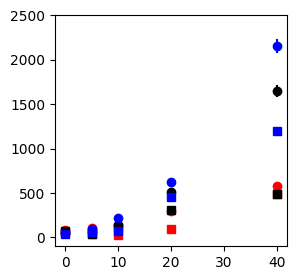

In [10]:
sub1=summary.loc[(summary['strain']=='A') & (summary['glucose']==2.5),['BE','median_gfp','std_gfp','n_cells']]
sub2=summary.loc[(summary['strain']=='B') & (summary['glucose']==2.5),['BE','median_gfp','std_gfp','n_cells']]
sub3=summary.loc[(summary['strain']=='C') & (summary['glucose']==2.5),['BE','median_gfp','std_gfp','n_cells']]

plt.errorbar(sub1['BE'],sub1['median_gfp'],yerr=sub1['std_gfp']/np.sqrt(sub1['n_cells']),color='red',fmt='o')
plt.errorbar(sub2['BE'],sub2['median_gfp'],yerr=sub2['std_gfp']/np.sqrt(sub2['n_cells']),color='black',fmt='o')
plt.errorbar(sub3['BE'],sub3['median_gfp'],yerr=sub3['std_gfp']/np.sqrt(sub3['n_cells']),color='blue',fmt='o')

sub1=summary.loc[(summary['strain']=='A') & (summary['glucose']==100),['BE','median_gfp','std_gfp','n_cells']]
sub2=summary.loc[(summary['strain']=='B') & (summary['glucose']==100),['BE','median_gfp','std_gfp','n_cells']]
sub3=summary.loc[(summary['strain']=='C') & (summary['glucose']==100),['BE','median_gfp','std_gfp','n_cells']]

plt.errorbar(sub1['BE'],sub1['median_gfp'],yerr=sub1['std_gfp']/np.sqrt(sub1['n_cells']),color='red',fmt='s')
plt.errorbar(sub2['BE'],sub2['median_gfp'],yerr=sub2['std_gfp']/np.sqrt(sub2['n_cells']),color='black',fmt='s')
plt.errorbar(sub3['BE'],sub3['median_gfp'],yerr=sub3['std_gfp']/np.sqrt(sub3['n_cells']),color='blue',fmt='s')


plt.ylim(-100,2500)

findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because

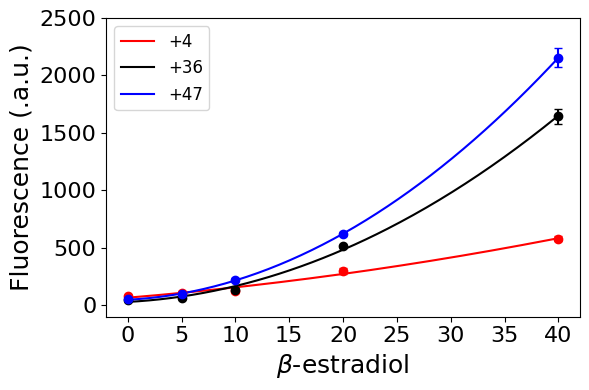

In [19]:
plt.figure(figsize=(6,4))


for strain, color in zip(['A', 'B', 'C'], ['red', 'black', 'blue']):

    sub = summary.loc[(summary['strain'] == strain) &
                      (summary['glucose'] == 2.5),
                      ['BE', 'median_gfp', 'std_gfp', 'n_cells']].dropna()

    x  = sub['BE'].values
    y  = sub['median_gfp'].values
    dy = sub['std_gfp'].values / np.sqrt(sub['n_cells'].values)

    # original data + error bars
    plt.errorbar(x, y, yerr=dy, fmt='o', color=color, capsize=3)

    # fit line through the same points
    coeffs = np.polyfit(x, y, deg=2)      # change deg if you want higher-order
    p = np.poly1d(coeffs)
    x_fit = np.linspace(x.min(), x.max(), 200)
    y_fit = p(x_fit)
    plt.plot(x_fit, y_fit, color=color, linestyle='-')

plt.legend(['+4','+36','+47'],fontsize=12)
plt.xticks(fontsize=16)
plt.yticks(fontsize=16)
plt.xlabel(r'$\beta$-estradiol',fontsize=18)
plt.ylabel(r'Fluorescence (.a.u.)',fontsize=18)
plt.ylim(-100, 2500)
plt.tight_layout()

mpl.rcParams['svg.fonttype'] = 'none'
mpl.rcParams['font.family'] = 'sans-serif'
mpl.rcParams['font.sans-serif'] = ['Arial']  # exists on Mac, Illustrator knows it
plt.tight_layout()
plt.savefig("glu_d005_scGFP_titration.svg", format="svg")

findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because

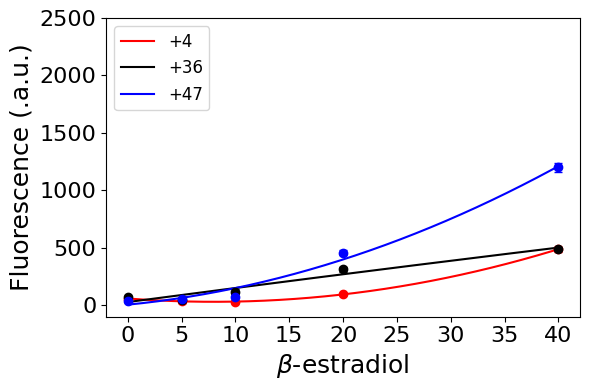

In [20]:
plt.figure(figsize=(6,4))

for strain, color in zip(['A', 'B', 'C'], ['red', 'black', 'blue']):

    sub = summary.loc[(summary['strain'] == strain) &
                      (summary['glucose'] == 100),
                      ['BE', 'median_gfp', 'std_gfp', 'n_cells']].dropna()

    x  = sub['BE'].values
    y  = sub['median_gfp'].values
    dy = sub['std_gfp'].values / np.sqrt(sub['n_cells'].values)

    # original data + error bars
    plt.errorbar(x, y, yerr=dy, fmt='o', color=color, capsize=3)

    # fit line through the same points
    coeffs = np.polyfit(x, y, deg=2)      # change deg if you want higher-order
    p = np.poly1d(coeffs)
    x_fit = np.linspace(x.min(), x.max(), 200)
    y_fit = p(x_fit)
    plt.plot(x_fit, y_fit, color=color, linestyle='-')

plt.legend(['+4','+36','+47'],fontsize=12,loc='upper left')
plt.xticks(fontsize=16)
plt.yticks(fontsize=16)
plt.xlabel(r'$\beta$-estradiol',fontsize=18)
plt.ylabel(r'Fluorescence (.a.u.)',fontsize=18)
plt.ylim(-100, 2500)
plt.tight_layout()
mpl.rcParams['svg.fonttype'] = 'none'
mpl.rcParams['font.family'] = 'sans-serif'
mpl.rcParams['font.sans-serif'] = ['Arial']  # exists on Mac, Illustrator knows it
plt.tight_layout()
plt.savefig("glu_d2_scGFP_titration.svg", format="svg")